# Stokes drift vs surface currents in the southern Kiel Bight

Comparing wave-driven Stokes drift against Eulerian surface currents
at the surface, 1.5m, and 3m depth in the region 9.75°E–11.0°E,
54.3°N–54.55°N. Stokes drift at 3m is estimated from surface values
using the deep water approximation: $u_{St}(z) = u_{St}(0) \exp(2kz)$
with $k$ from the peak period.

In [1]:
import copernicusmarine as cm
import matplotlib.pyplot as plt
import numpy as np

LON = slice(9.75, 11.0)
LAT = slice(54.3, 54.55)
TIME = slice("2023-04-24", "2023-04-27")

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
# Stokes drift (surface only — depth profile estimated below)
ds_wav = cm.open_dataset(
    dataset_id="cmems_mod_bal_wav_anfc_PT1H-i",
    service="arco-geo-series",
).sel(longitude=LON, latitude=LAT, time=TIME)[["VSDX", "VSDY", "VHM0", "VTPK"]].load()

ds_wav = ds_wav.assign_coords(
    longitude=np.linspace(float(ds_wav.longitude[0]), float(ds_wav.longitude[-1]), len(ds_wav.longitude)),
    latitude=np.linspace(float(ds_wav.latitude[0]), float(ds_wav.latitude[-1]), len(ds_wav.latitude)),
)
ds_wav["stokes_speed"] = np.sqrt(ds_wav["VSDX"]**2 + ds_wav["VSDY"]**2)

# Estimated Stokes at depth: deep water approx u_St(z) = u_St(0) * exp(2kz)
# k = (2*pi)^2 / (g * Tp^2) for deep water
g = 9.81
k = (2 * np.pi)**2 / (g * ds_wav["VTPK"]**2)
ds_wav["stokes_speed_3m"] = ds_wav["stokes_speed"] * np.exp(-2 * k * 3.0)

# Eulerian currents at surface, 1.5m, 3m
ds_phy_full = cm.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_PT1H-i",
    service="arco-geo-series",
).sel(longitude=LON, latitude=LAT, time=TIME)

depths = {"0m": 0, "1.5m": 1.5, "3m": 3}
ds_phy = {}
for label, z in depths.items():
    d = ds_phy_full.sel(depth=z, method="nearest")[["uo", "vo"]].load()
    d = d.assign_coords(
        longitude=np.linspace(float(d.longitude[0]), float(d.longitude[-1]), len(d.longitude)),
        latitude=np.linspace(float(d.latitude[0]), float(d.latitude[-1]), len(d.latitude)),
    )
    d["speed"] = np.sqrt(d["uo"]**2 + d["vo"]**2)
    ds_phy[label] = d

INFO - 2026-03-25T09:29:00Z - Selected dataset version: "202311"


INFO - 2026-03-25T09:29:00Z - Selected dataset part: "default"


INFO - 2026-03-25T09:29:10Z - Selected dataset version: "202411"


INFO - 2026-03-25T09:29:10Z - Selected dataset part: "default"


WARNING - 2026-03-25T09:29:10Z - The dataset cmems_mod_bal_phy_anfc_PT1H-i, version '202411', part 'default' is currently being updated. Data after 2026-03-25T00:00:00.000Z may not be up to date.


## Mean fields side by side

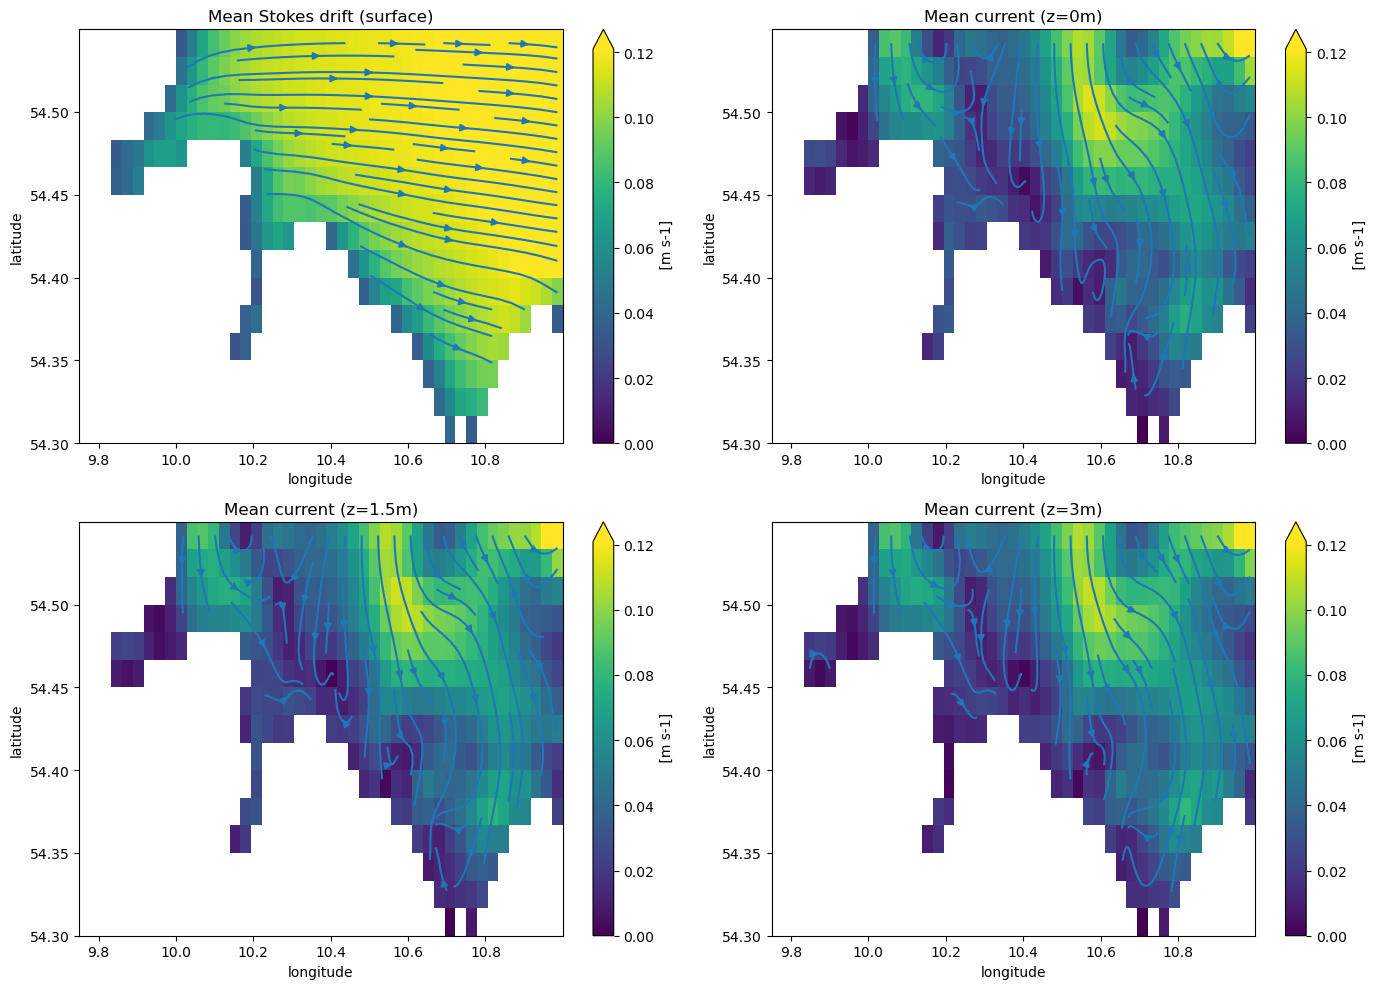

In [3]:
# Compute common vmax from P95 of all mean speeds
all_mean_speeds = np.concatenate([
    np.sqrt(ds_wav[["VSDX", "VSDY"]].mean("time")["VSDX"]**2 +
            ds_wav[["VSDX", "VSDY"]].mean("time")["VSDY"]**2).values.ravel(),
] + [
    np.sqrt(d[["uo", "vo"]].mean("time")["uo"]**2 +
            d[["uo", "vo"]].mean("time")["vo"]**2).values.ravel()
    for d in ds_phy.values()
])
vmax_mean = float(np.nanpercentile(all_mean_speeds, 95))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stokes_mean = ds_wav[["VSDX", "VSDY"]].mean("time")
np.sqrt(stokes_mean["VSDX"]**2 + stokes_mean["VSDY"]**2).plot(ax=axes[0, 0], vmin=0, vmax=vmax_mean)
stokes_mean.plot.streamplot(x="longitude", y="latitude", u="VSDX", v="VSDY", ax=axes[0, 0])
axes[0, 0].set_title("Mean Stokes drift (surface)")

for label, d in ds_phy.items():
    ax = {"0m": axes[0, 1], "1.5m": axes[1, 0], "3m": axes[1, 1]}[label]
    dm = d[["uo", "vo"]].mean("time")
    np.sqrt(dm["uo"]**2 + dm["vo"]**2).plot(ax=ax, vmin=0, vmax=vmax_mean)
    dm.plot.streamplot(x="longitude", y="latitude", u="uo", v="vo", ax=ax)
    ax.set_title(f"Mean current (z={label})")

plt.tight_layout()
plt.show()

## Ratio: Stokes / (Stokes + current)

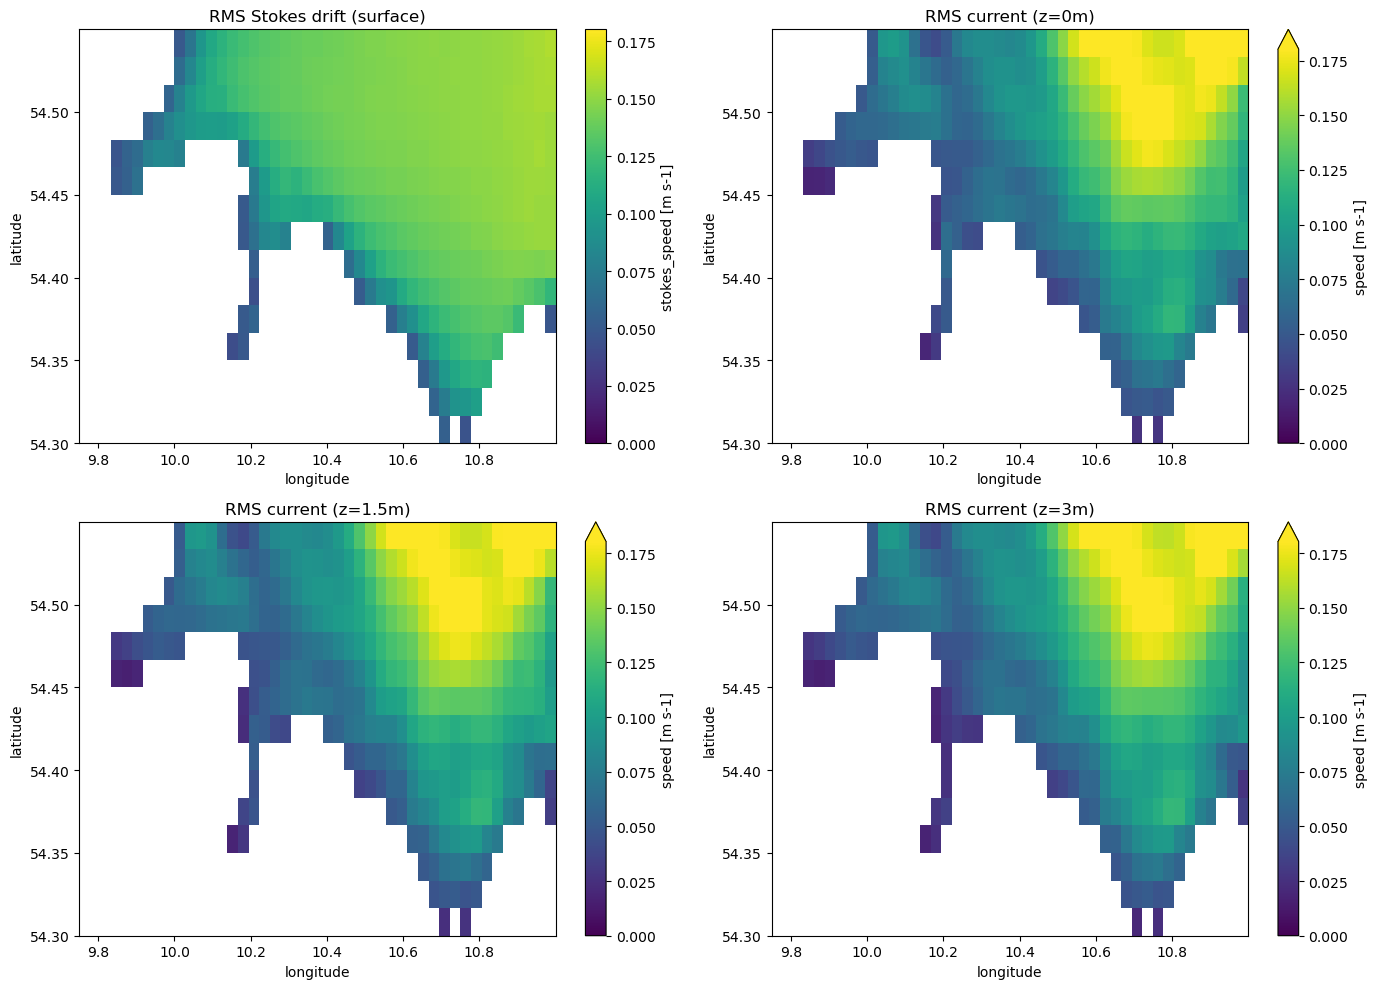

In [4]:
# RMS speed: unified color scale
all_rms = np.concatenate([
    np.sqrt((ds_wav["stokes_speed"]**2).mean("time")).values.ravel(),
] + [
    np.sqrt((d["speed"]**2).mean("time")).values.ravel()
    for d in ds_phy.values()
])
vmax_rms = float(np.nanpercentile(all_rms, 95))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

np.sqrt((ds_wav["stokes_speed"]**2).mean("time")).plot(ax=axes[0, 0], vmin=0, vmax=vmax_rms)
axes[0, 0].set_title("RMS Stokes drift (surface)")

for label, d in ds_phy.items():
    ax = {"0m": axes[0, 1], "1.5m": axes[1, 0], "3m": axes[1, 1]}[label]
    np.sqrt((d["speed"]**2).mean("time")).plot(ax=ax, vmin=0, vmax=vmax_rms)
    ax.set_title(f"RMS current (z={label})")

plt.tight_layout()
plt.show()

## Median speed across the region

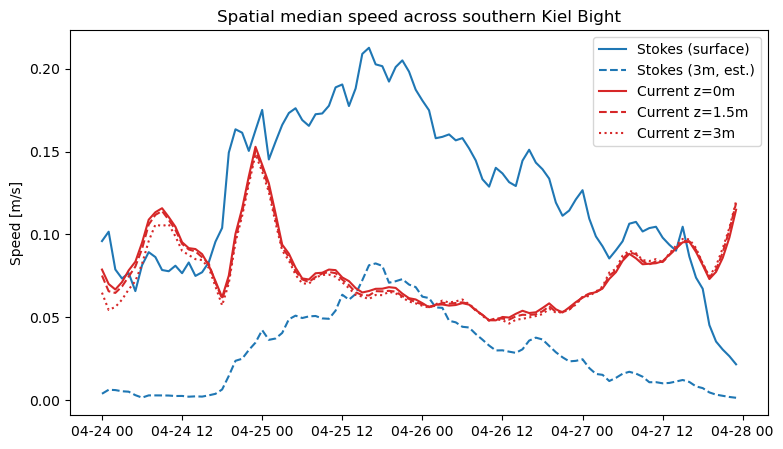

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

# Stokes: blue, depths via linestyle
stokes_median = ds_wav["stokes_speed"].median(["longitude", "latitude"])
stokes_3m_median = ds_wav["stokes_speed_3m"].median(["longitude", "latitude"])
ax.plot(stokes_median.time, stokes_median, color="tab:blue", linestyle="-", label="Stokes (surface)")
ax.plot(stokes_3m_median.time, stokes_3m_median, color="tab:blue", linestyle="--", label="Stokes (3m, est.)")

# Currents: red, depths via linestyle
depth_styles = {"0m": "-", "1.5m": "--", "3m": ":"}
for label, d in ds_phy.items():
    median_ts = d["speed"].median(["longitude", "latitude"])
    ax.plot(median_ts.time, median_ts, color="tab:red", linestyle=depth_styles[label], label=f"Current z={label}")

ax.set_ylabel("Speed [m/s]")
ax.set_title("Spatial median speed across southern Kiel Bight")
ax.legend()
plt.show()

## Summary statistics

In [6]:
print(f"Southern Kiel Bight, {TIME.start} to {TIME.stop}:")
print(f"{'':>20s} {'Stokes 0m':>10s} {'Stokes 3m':>10s} {'Curr 0m':>10s} {'Curr 1.5m':>10s} {'Curr 3m':>10s}")

fields = {
    "Stokes 0m": ds_wav["stokes_speed"],
    "Stokes 3m": ds_wav["stokes_speed_3m"],
    "Curr 0m": ds_phy["0m"]["speed"],
    "Curr 1.5m": ds_phy["1.5m"]["speed"],
    "Curr 3m": ds_phy["3m"]["speed"],
}

for stat, func in [("Mean", lambda x: float(x.mean())),
                    ("RMS", lambda x: float(np.sqrt((x**2).mean()))),
                    ("Max", lambda x: float(x.max())),
                    ("P95", lambda x: float(x.quantile(0.95)))]:
    vals = [func(f) for f in fields.values()]
    print(f"{stat:>20s}" + "".join(f"{v:10.4f}" for v in vals))

Southern Kiel Bight, 2023-04-24 to 2023-04-27:
                      Stokes 0m  Stokes 3m    Curr 0m  Curr 1.5m    Curr 3m
                Mean    0.1176    0.0265    0.0905    0.0896    0.0880
                 RMS    0.1294    0.0375    0.1128    0.1120    0.1103
                 Max    0.2434    0.1167    0.4375    0.4347    0.4321
                 P95    0.2059    0.0833    0.2272    0.2257    0.2229
